# AI Student Performance Analysis Using Generative AI

## Abstract
This project analyzes the relationship between Generative AI usage, study habits, prompt engineering skills, and student academic performance. The workflow follows the CRISP-DM methodology and includes data cleaning, exploratory data analysis, feature engineering, model building, and evaluation.

## CRISP-DM Methodology
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation


In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Data Understanding

This section loads the dataset and explores its structure, dimensions, columns, and data types.

In [78]:
#my file path = 'C:/Users/Prameel/Desktop/NASSCOM/NASSCOM-Training-/Project/AI_Student_performance_50000_with_Errors.csv'

df = pd.read_csv('C:/Users/Prameel/Desktop/NASSCOM/NASSCOM-Training-/Project/AI_Student_performance_50000_with_Errors.csv')

Understand the dataset

In [79]:
print("Rows and Columns:", df.shape)

Rows and Columns: (51000, 16)


In [80]:
#view sample records
print(df.head())

   Student_ID Major_Category Year_of_Study  Pre_Semester_GPA  \
0      100001        Medical     Sophomore             3.192   
1      100002     Humanities     Sophomore             3.683   
2      100003           STEM        Senior             3.450   
3      100004        Medical      Freshman             2.878   
4      100005        Medical        Junior             3.915   

   Weekly_GenAI_Hours           Primary_Use_Case Prompt_Engineering_Skill  \
0                7.78       Copywriting/Drafting                 Advanced   
1               22.29  Debugging/Troubleshooting             Intermediate   
2                3.57        Summarizing_Reading                 Beginner   
3               11.37       Copywriting/Drafting             Intermediate   
4               28.16                   Ideation                 Beginner   

   Tool_Diversity  Paid_Subscription  Traditional_Study_Hours  \
0               4              False                     7.77   
1               2     

In [81]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  51000 non-null  int64  
 1   Major_Category              51000 non-null  str    
 2   Year_of_Study               51000 non-null  str    
 3   Pre_Semester_GPA            49470 non-null  float64
 4   Weekly_GenAI_Hours          49476 non-null  float64
 5   Primary_Use_Case            51000 non-null  str    
 6   Prompt_Engineering_Skill    49470 non-null  str    
 7   Tool_Diversity              51000 non-null  int64  
 8   Paid_Subscription           51000 non-null  bool   
 9   Traditional_Study_Hours     49475 non-null  float64
 10  Perceived_AI_Dependency     51000 non-null  int64  
 11  Institutional_Policy        51000 non-null  str    
 12  Anxiety_Level_During_Exams  51000 non-null  int64  
 13  Post_Semester_GPA           51000 non-null

In [82]:
df.dtypes

Student_ID                      int64
Major_Category                    str
Year_of_Study                     str
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case                  str
Prompt_Engineering_Skill          str
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy              str
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level                str
dtype: object

## Data Cleaning

Data quality issues such as missing values, duplicates, inconsistent formatting, and invalid entries are identified and corrected.

In [83]:
df.isnull().sum()

Student_ID                       0
Major_Category                   0
Year_of_Study                    0
Pre_Semester_GPA              1530
Weekly_GenAI_Hours            1524
Primary_Use_Case                 0
Prompt_Engineering_Skill      1530
Tool_Diversity                   0
Paid_Subscription                0
Traditional_Study_Hours       1525
Perceived_AI_Dependency          0
Institutional_Policy             0
Anxiety_Level_During_Exams       0
Post_Semester_GPA                0
Skill_Retention_Score         1522
Burnout_Risk_Level               0
dtype: int64

In [84]:
(df.isnull().sum()/len(df))*100

Student_ID                    0.000000
Major_Category                0.000000
Year_of_Study                 0.000000
Pre_Semester_GPA              3.000000
Weekly_GenAI_Hours            2.988235
Primary_Use_Case              0.000000
Prompt_Engineering_Skill      3.000000
Tool_Diversity                0.000000
Paid_Subscription             0.000000
Traditional_Study_Hours       2.990196
Perceived_AI_Dependency       0.000000
Institutional_Policy          0.000000
Anxiety_Level_During_Exams    0.000000
Post_Semester_GPA             0.000000
Skill_Retention_Score         2.984314
Burnout_Risk_Level            0.000000
dtype: float64

In [85]:
df.duplicated().sum()

636

In [86]:
df.drop_duplicates(inplace=True)
print(df)

       Student_ID Major_Category Year_of_Study  Pre_Semester_GPA  \
0          100001        Medical     Sophomore             3.192   
1          100002     Humanities     Sophomore             3.683   
2          100003           STEM        Senior             3.450   
3          100004        Medical      Freshman             2.878   
4          100005        Medical        Junior             3.915   
...           ...            ...           ...               ...   
50982      148706           STEM        Senior             2.246   
50984      118786           STEM      Freshman             3.067   
50987      133986        Medical     Sophomore             3.203   
50988      111626        Medical      Freshman             3.267   
50992      143512           STEM      Freshman             3.312   

       Weekly_GenAI_Hours           Primary_Use_Case Prompt_Engineering_Skill  \
0                    7.78       Copywriting/Drafting                 Advanced   
1                   2

In [87]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50364.000000,48834.000000,48840.000000,50364.000000,48840.000000,50364.000000,50364.000000,50364.000000,48842.000000
mean,124999.180208,3.198821,10.462221,3.000298,12.194850,3.002343,5.512310,3.238701,74.902015
std,14436.998487,0.392750,9.828805,1.411649,5.409213,1.414001,2.871882,0.431002,15.163235
min,100001.000000,1.415000,0.020000,1.000000,0.000000,1.000000,1.000000,1.077000,11.590000
25%,112498.750000,2.933000,4.870000,2.000000,9.300000,2.000000,3.000000,2.943000,64.870000
50%,124996.500000,3.203000,8.480000,3.000000,12.010000,3.000000,6.000000,3.248000,75.000000
75%,137505.250000,3.472000,13.550000,4.000000,14.720000,4.000000,8.000000,3.552000,85.200000
max,150000.000000,4.000000,149.811876,5.000000,99.654631,5.000000,10.000000,4.000000,199.825455


In [88]:
df.describe(include='object')

C:\Users\Prameel\AppData\Local\Temp\ipykernel_32016\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Major_Category,Year_of_Study,Primary_Use_Case,Prompt_Engineering_Skill,Institutional_Policy,Burnout_Risk_Level
count,50364,50364,50364,48834,50364,50364
unique,7,8,8,3,3,4
top,STEM,Sophomore,Summarizing_Reading,Intermediate,Strict_Ban,Low
freq,12700,12606,12450,19695,16869,20130


In [89]:
for col in df.select_dtypes(include='object').columns:
    print("\n", col)
    print(df[col].unique())


 Major_Category
<StringArray>
[   'Medical', 'Humanities',       'STEM',   'Business',    'MEDICAL',
 'HUMANITIES',   'BUSINESS']
Length: 7, dtype: str

 Year_of_Study
<StringArray>
[  'Sophomore',      'Senior',    'Freshman',      'Junior',    ' Senior ',
  ' Freshman ', ' Sophomore ',    ' Junior ']
Length: 8, dtype: str

 Primary_Use_Case
<StringArray>
[     'Copywriting/Drafting', 'Debugging/Troubleshooting',
       'Summarizing_Reading',                  'Ideation',
 'DEBUGGING/TROUBLESHOOTING',       'SUMMARIZING_READING',
      'COPYWRITING/DRAFTING',                  'IDEATION']
Length: 8, dtype: str

 Prompt_Engineering_Skill
<StringArray>
['Advanced', 'Intermediate', 'Beginner', nan]
Length: 4, dtype: str

 Institutional_Policy
<StringArray>
['Allowed_With_Disclosure', 'Strict_Ban', 'Allowed_With_Citation']
Length: 3, dtype: str

 Burnout_Risk_Level
<StringArray>
['High', 'Medium', 'Low', 'Unknown']
Length: 4, dtype: str


C:\Users\Prameel\AppData\Local\Temp\ipykernel_32016\3835539417.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [90]:
# checking missing values again
print(df.isnull().sum())

Student_ID                       0
Major_Category                   0
Year_of_Study                    0
Pre_Semester_GPA              1530
Weekly_GenAI_Hours            1524
Primary_Use_Case                 0
Prompt_Engineering_Skill      1530
Tool_Diversity                   0
Paid_Subscription                0
Traditional_Study_Hours       1524
Perceived_AI_Dependency          0
Institutional_Policy             0
Anxiety_Level_During_Exams       0
Post_Semester_GPA                0
Skill_Retention_Score         1522
Burnout_Risk_Level               0
dtype: int64


In [91]:
print(df.dtypes)

Student_ID                      int64
Major_Category                    str
Year_of_Study                     str
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case                  str
Prompt_Engineering_Skill          str
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy              str
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level                str
dtype: object


In [92]:
#stduent id  is a identifier
df['Student_ID'] = df['Student_ID'].astype(str)
print(df['Student_ID'].dtype)

str


In [93]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()
print(df[col])

C:\Users\Prameel\AppData\Local\Temp\ipykernel_32016\3489182982.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


0          High
1        Medium
2        Medium
3        Medium
4          High
          ...  
50982      High
50984      High
50987      High
50988    Medium
50992       Low
Name: Burnout_Risk_Level, Length: 50364, dtype: str


In [94]:
df['Major_Category'] = (
    df['Major_Category']
    .str.strip()
    .str.title()
)

In [95]:
df['Primary_Use_Case'] = (
    df['Primary_Use_Case']
    .str.strip()
    .str.title()
)

In [96]:
df['Prompt_Engineering_Skill'] = (
    df['Prompt_Engineering_Skill']
    .str.strip()
    .str.title()
)

In [97]:
print(df['Major_Category'].unique())
print(df['Primary_Use_Case'].unique())

<StringArray>
['Medical', 'Humanities', 'Stem', 'Business']
Length: 4, dtype: str
<StringArray>
[     'Copywriting/Drafting', 'Debugging/Troubleshooting',
       'Summarizing_Reading',                  'Ideation']
Length: 4, dtype: str


In [98]:
print(df.duplicated().sum())

63


In [99]:
df.drop_duplicates(inplace=True)

In [100]:
df.describe()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,48771.000000,48777.000000,50301.000000,48777.000000,50301.000000,50301.000000,50301.000000,48779.000000
mean,3.198760,10.463659,3.000378,12.194703,3.002127,5.512475,3.238732,74.902750
std,0.392769,9.832689,1.411589,5.410854,1.414036,2.872110,0.431021,15.162222
min,1.415000,0.020000,1.000000,0.000000,1.000000,1.000000,1.077000,11.590000
25%,2.933000,4.870000,2.000000,9.300000,2.000000,3.000000,2.943000,64.870000
50%,3.203000,8.480000,3.000000,12.010000,3.000000,6.000000,3.248000,75.000000
75%,3.472000,13.550000,4.000000,14.720000,4.000000,8.000000,3.552000,85.200000
max,4.000000,149.811876,5.000000,99.654631,5.000000,10.000000,4.000000,199.825455


In [101]:
Q1 = df['Skill_Retention_Score'].quantile(0.25)
Q3 = df['Skill_Retention_Score'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Skill_Retention_Score'] < lower) |
    (df['Skill_Retention_Score'] > upper)
]

print(len(outliers))

317


In [102]:
df = df[
    (df['Skill_Retention_Score'] >= lower) &
    (df['Skill_Retention_Score'] <= upper)
]

In [103]:
df[
    (df['Pre_Semester_GPA'] < 0) |
    (df['Pre_Semester_GPA'] > 4)
]

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level


In [104]:
df[
    (df['Post_Semester_GPA'] < 0) |
    (df['Post_Semester_GPA'] > 4)
]

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level


In [105]:
df['Weekly_GenAI_Hours'].describe()

count    47010.000000
mean        10.452226
std          9.827508
min          0.020000
25%          4.860000
50%          8.470000
75%         13.530000
max        149.811876
Name: Weekly_GenAI_Hours, dtype: float64

In [106]:
df['Traditional_Study_Hours'].describe()

count    46993.000000
mean        12.193587
std          5.431345
min          0.000000
25%          9.300000
50%         12.010000
75%         14.710000
max         99.654631
Name: Traditional_Study_Hours, dtype: float64

In [107]:
for col in [
    'Major_Category',
    'Prompt_Engineering_Skill',
    'Primary_Use_Case'
]:
    print("\n", col)
    print(df[col].value_counts())


 Major_Category
Major_Category
Stem          12223
Humanities    12138
Medical       12055
Business      12046
Name: count, dtype: int64

 Prompt_Engineering_Skill
Prompt_Engineering_Skill
Intermediate    18958
Beginner        18645
Advanced         9379
Name: count, dtype: int64

 Primary_Use_Case
Primary_Use_Case
Summarizing_Reading          12230
Copywriting/Drafting         12136
Debugging/Troubleshooting    12050
Ideation                     12046
Name: count, dtype: int64


In [108]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 48462 entries, 0 to 50992
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  48462 non-null  str    
 1   Major_Category              48462 non-null  str    
 2   Year_of_Study               48462 non-null  str    
 3   Pre_Semester_GPA            46981 non-null  float64
 4   Weekly_GenAI_Hours          47010 non-null  float64
 5   Primary_Use_Case            48462 non-null  str    
 6   Prompt_Engineering_Skill    46982 non-null  str    
 7   Tool_Diversity              48462 non-null  int64  
 8   Paid_Subscription           48462 non-null  bool   
 9   Traditional_Study_Hours     46993 non-null  float64
 10  Perceived_AI_Dependency     48462 non-null  int64  
 11  Institutional_Policy        48462 non-null  str    
 12  Anxiety_Level_During_Exams  48462 non-null  int64  
 13  Post_Semester_GPA           48462 non-null  flo

In [109]:
print(df.isnull().sum())

Student_ID                       0
Major_Category                   0
Year_of_Study                    0
Pre_Semester_GPA              1481
Weekly_GenAI_Hours            1452
Primary_Use_Case                 0
Prompt_Engineering_Skill      1480
Tool_Diversity                   0
Paid_Subscription                0
Traditional_Study_Hours       1469
Perceived_AI_Dependency          0
Institutional_Policy             0
Anxiety_Level_During_Exams       0
Post_Semester_GPA                0
Skill_Retention_Score            0
Burnout_Risk_Level               0
dtype: int64


In [110]:
print(df.duplicated().sum())

0


In [111]:
print(df.shape)

(48462, 16)


In [112]:
df.to_csv(
    "AI_Student_Performance_Cleaned.csv",
    index=False
)

EDA: the goal is " what stories is the data is telling us?"

In [113]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pre_Semester_GPA,46981.0,3.198608,0.392606,1.415,2.933,3.202,3.472,4.000000
Weekly_GenAI_Hours,47010.0,10.452226,9.827508,0.020,4.860,8.470,13.530,149.811876
Tool_Diversity,48462.0,3.000887,1.411475,1.000,2.000,3.000,4.000,5.000000
Traditional_Study_Hours,46993.0,12.193587,5.431345,0.000,9.300,12.010,14.710,99.654631
Perceived_AI_Dependency,48462.0,3.003013,1.413524,1.000,2.000,3.000,4.000,5.000000
Anxiety_Level_During_Exams,48462.0,5.510895,2.872879,1.000,3.000,6.000,8.000,10.000000
Post_Semester_GPA,48462.0,3.238662,0.430606,1.077,2.943,3.248,3.551,4.000000
Skill_Retention_Score,48462.0,74.798340,14.174867,34.380,64.950,75.010,85.130,100.000000


lets look at mean, median,min,max,std , what is the average GPA ? Average GenAI usage? Average retenion score?

## Exploratory Data Analysis (EDA)

EDA helps uncover trends, distributions, correlations, and patterns that support decision-making and model development.

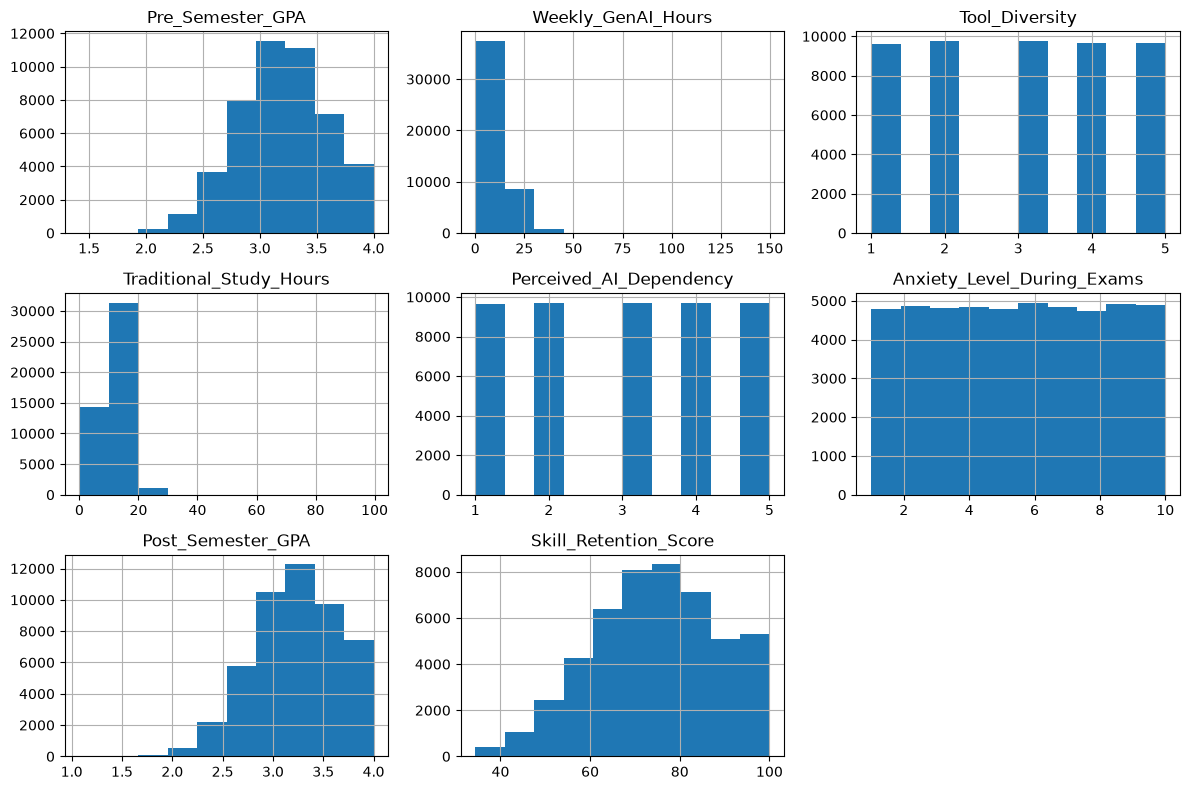

In [114]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

Observe : normal distibution? skewed? Mutiple peaks? 


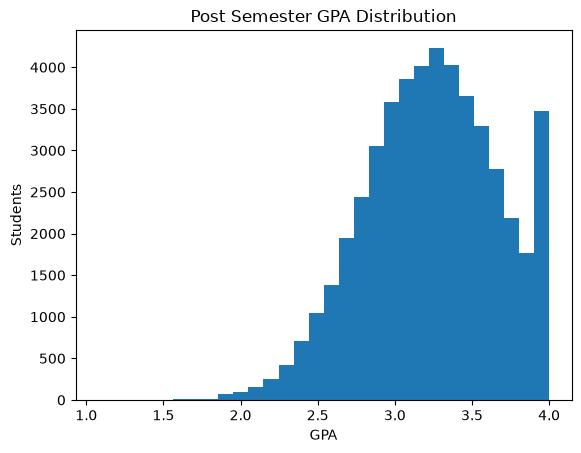

In [115]:
plt.hist(df['Post_Semester_GPA'], bins=30)
plt.title("Post Semester GPA Distribution")
plt.xlabel("GPA")
plt.ylabel("Students")
plt.show()

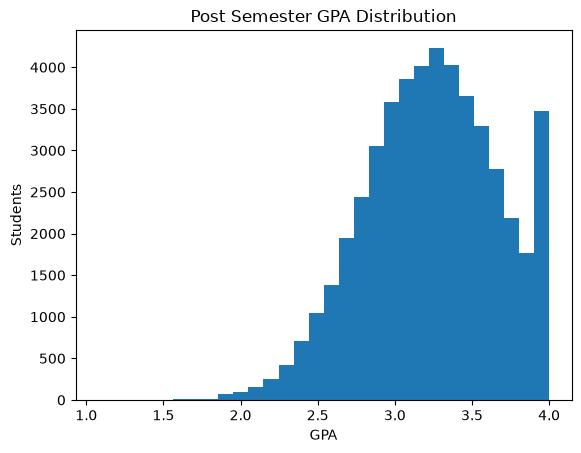

In [116]:
plt.hist(df['Post_Semester_GPA'], bins=30)
plt.title("Post Semester GPA Distribution")
plt.xlabel("GPA")
plt.ylabel("Students")
plt.show()

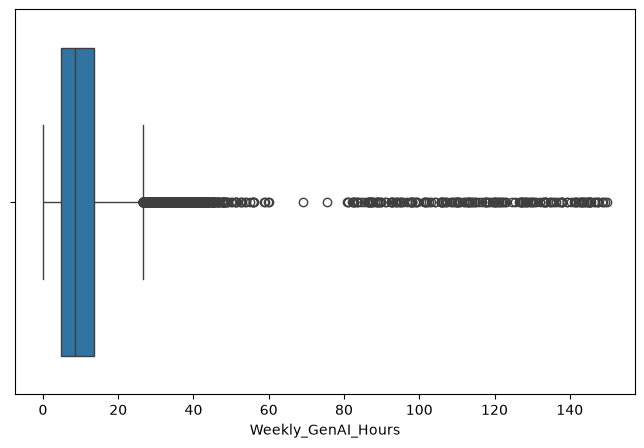

In [117]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Weekly_GenAI_Hours'])
plt.show()

In [118]:
corr = df.select_dtypes(include=['int64','float64']).corr()

corr

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
Pre_Semester_GPA,1.000000,0.000854,0.002472,-0.001332,-0.001736,-0.000514,0.007810,0.006272
Weekly_GenAI_Hours,0.000854,1.000000,0.005488,-0.007209,-0.006868,0.006285,0.000999,0.000228
Tool_Diversity,0.002472,0.005488,1.000000,0.009935,-0.005576,-0.002422,-0.006977,-0.005159
Traditional_Study_Hours,-0.001332,-0.007209,0.009935,1.000000,0.002303,0.003985,-0.005404,0.001189
Perceived_AI_Dependency,-0.001736,-0.006868,-0.005576,0.002303,1.000000,0.004377,-0.001041,-0.000931
Anxiety_Level_During_Exams,-0.000514,0.006285,-0.002422,0.003985,0.004377,1.000000,-0.009204,-0.000905
Post_Semester_GPA,0.007810,0.000999,-0.006977,-0.005404,-0.001041,-0.009204,1.000000,0.001094
Skill_Retention_Score,0.006272,0.000228,-0.005159,0.001189,-0.000931,-0.000905,0.001094,1.000000


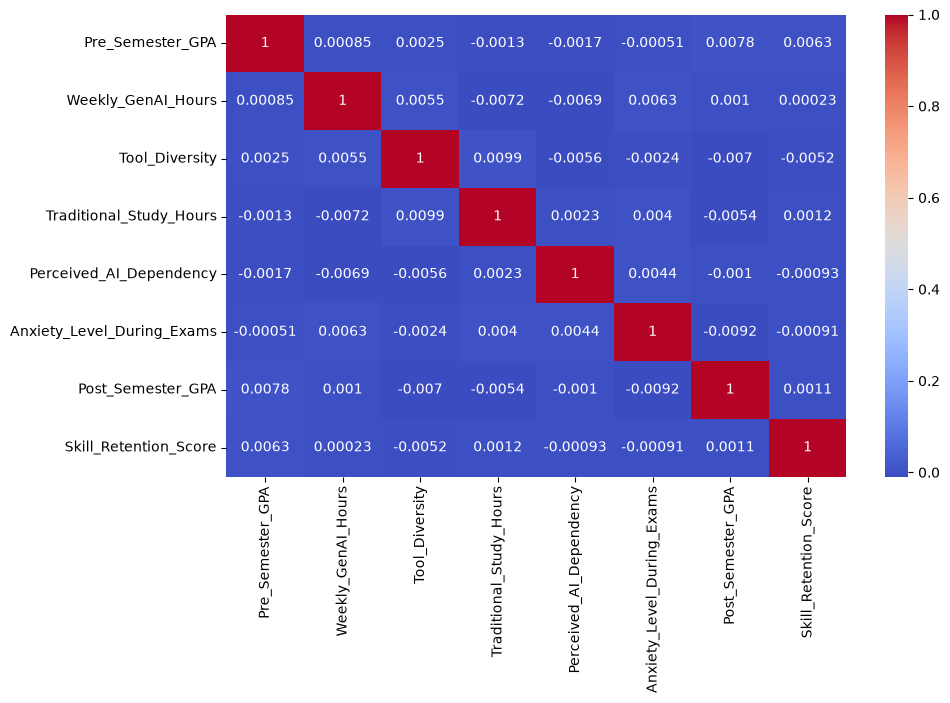

In [119]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

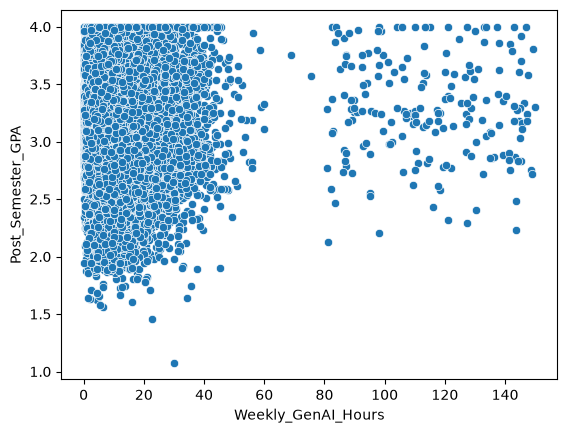

In [120]:
sns.scatterplot(
    x='Weekly_GenAI_Hours',
    y='Post_Semester_GPA',
    data=df
)

plt.show()

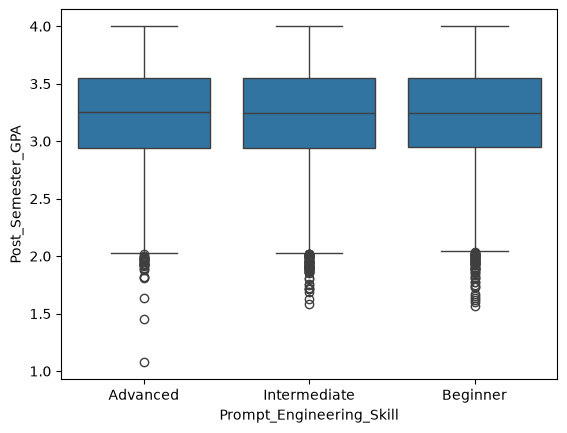

In [121]:
sns.boxplot(
    x='Prompt_Engineering_Skill',
    y='Post_Semester_GPA',
    data=df
)

plt.show()

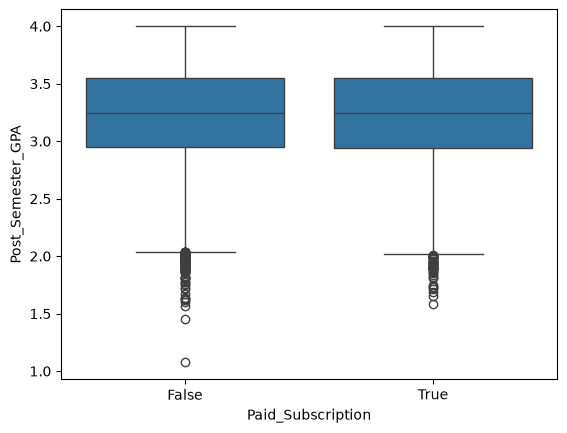

In [122]:
sns.boxplot(
    x='Paid_Subscription',
    y='Post_Semester_GPA',
    data=df
)

plt.show()

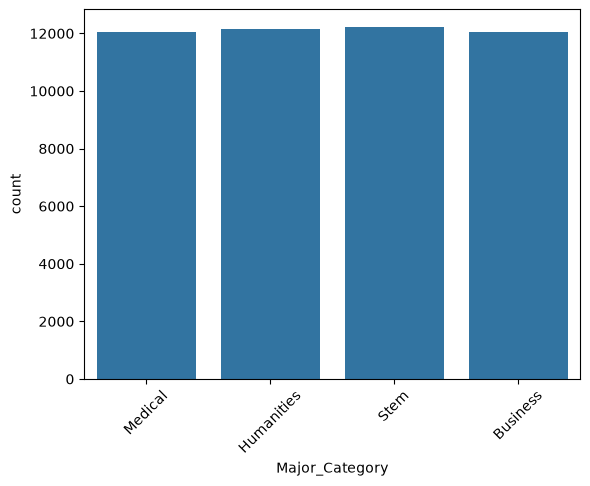

In [123]:
sns.countplot(
    x='Major_Category',
    data=df
)

plt.xticks(rotation=45)
plt.show()

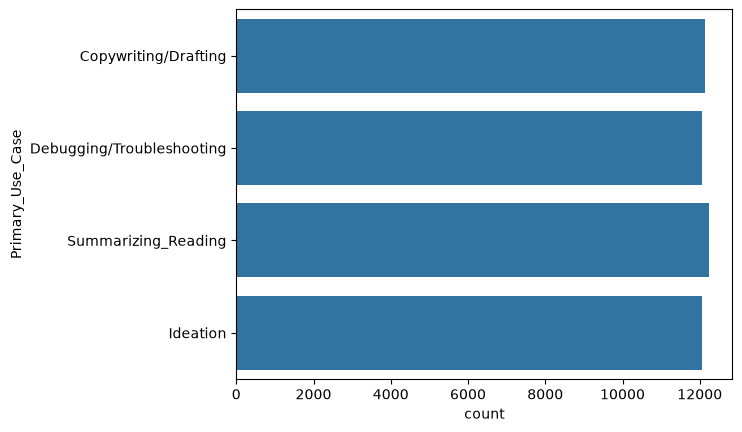

In [124]:
sns.countplot(
    y='Primary_Use_Case',
    data=df
)

plt.show()

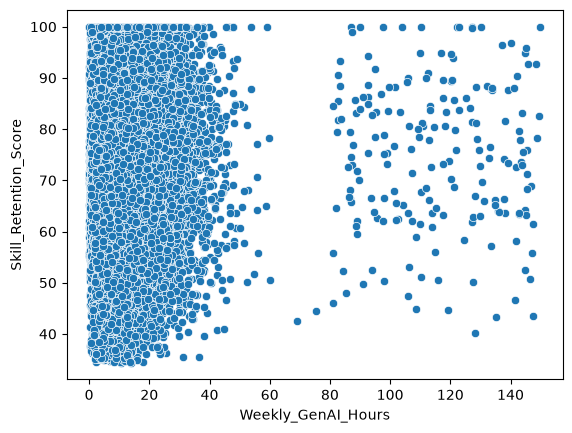

In [125]:
sns.scatterplot(
    x='Weekly_GenAI_Hours',
    y='Skill_Retention_Score',
    data=df
)

plt.show()

Feature Engineering

In [126]:
X = df.drop('Post_Semester_GPA', axis=1)
y = df['Post_Semester_GPA']

In [127]:
X = X.drop('Student_ID', axis=1)

In [128]:
print(X.dtypes)

Major_Category                    str
Year_of_Study                     str
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case                  str
Prompt_Engineering_Skill          str
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy              str
Anxiety_Level_During_Exams      int64
Skill_Retention_Score         float64
Burnout_Risk_Level                str
dtype: object


## Feature Engineering and Preprocessing

Categorical variables are encoded and numerical variables are scaled to prepare data for machine learning algorithms.

In [129]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [130]:
X.head()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Skill_Retention_Score,Major_Category_Humanities,Major_Category_Medical,...,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Allowed_With_Disclosure,Institutional_Policy_Strict_Ban,Burnout_Risk_Level_Low,Burnout_Risk_Level_Medium,Burnout_Risk_Level_Unknown
0,3.192,7.78,4,False,7.77,1,1,83.95,False,True,...,False,False,False,False,False,True,False,False,False,False
1,3.683,22.29,2,False,17.04,3,4,81.22,True,False,...,True,False,False,False,True,True,False,False,True,False
2,3.450,3.57,3,False,9.38,1,3,100.00,False,False,...,False,False,True,True,False,False,True,False,True,False
3,2.878,11.37,1,True,NaN,1,10,72.90,False,True,...,False,False,False,False,True,True,False,False,True,False
5,2.586,5.28,2,False,16.26,2,3,81.72,True,False,...,False,False,True,False,True,False,True,False,True,False


In [131]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [132]:
print(X_train.shape)
print(X_test.shape)

(38769, 24)
(9693, 24)


In [133]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [134]:
print(X_train_scaled[:5])

[[-1.11844397 -0.0044585   1.42320243  1.53050427 -0.24760349 -0.00195532
   0.16729435 -0.75841867 -0.57734034  1.72271929 -0.57928624 -0.57471932
  -0.57948481 -0.57928624 -0.57456047  1.73530338 -0.58023935 -0.79207127
   1.24934754 -0.70624516 -0.70879     1.22320617 -0.81283345 -0.06577386]
 [-0.14077865 -0.94857272  0.00395365 -0.65337943  0.60259865 -0.7104216
  -1.57546001  0.46672908  1.73208059 -0.58047762 -0.57928624 -0.57471932
   1.72567079 -0.57928624 -0.57456047  1.73530338 -0.58023935 -0.79207127
  -0.80041779 -0.70624516 -0.70879     1.22320617 -0.81283345 -0.06577386]
 [-0.06439854  0.29875327  0.00395365 -0.65337943 -0.22362815  0.70651096
  -0.5298074   0.35317192 -0.57734034  1.72271929 -0.57928624  1.73997977
  -0.57948481 -0.57928624 -0.57456047  1.73530338 -0.58023935 -0.79207127
   1.24934754 -0.70624516 -0.70879    -0.81752367  1.23026433 -0.06577386]
 [-0.72635944  0.05233033  1.42320243  1.53050427  1.02493333  0.70651096
  -1.22690914  1.04438942 -0.5773403

## Model Building

Regression models are trained to predict Post_Semester_GPA using the prepared features.

In [135]:
from sklearn.linear_model import LinearRegression

In [136]:
model = LinearRegression()

In [138]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)

model.fit(
    X_train_scaled,
    y_train
)

LinearRegression()

In [139]:
y_pred = model.predict(X_test_scaled)

## Model Evaluation

Model performance is measured using MSE and R² Score.

In [141]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    y_test,
    y_pred
)

print("MSE:", mse)

MSE: 0.18789788778105765


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(
    y_test,
    y_pred
)

print("R²:", r2)

R²: -0.001135578650935054


In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

print(
    r2_score(y_test, ridge_pred)
)

-0.0011355290046131117


In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

print(
    r2_score(y_test, lasso_pred)
)

-1.6534133662204908e-06


# Conclusion

## Key Activities Performed
- Data loading and inspection
- Missing value treatment
- Duplicate and inconsistency handling
- Exploratory Data Analysis
- Feature Engineering
- One-Hot Encoding
- Feature Scaling
- Regression Modeling
- Model Evaluation

## Key Insights
- Student performance can be analyzed using academic, behavioral, and AI-usage features.
- Data cleaning significantly improves dataset quality.
- EDA helps identify meaningful relationships among variables.
- Regression models provide a quantitative way to predict academic performance.

## Future Scope
- Hyperparameter tuning
- Cross-validation
- Ensemble methods
- Advanced feature selection
- Model deployment and monitoring
